# December 2018: SMEs Survey

Sample Size: 5,566 Algeria respondents to 31 questions

This analysis examines small and medium enterprise survey data from Algeria, focusing on business characteristics, income sources, skills, social media usage, community challenges, and work roles.

In [135]:
import pandas as pd

In [136]:
df = pd.read_csv('../../data/business_survey_msme/FoB Survey microdata (waves 1-12)/fob_winter_2018/fob_1218_data_default_version/fob_1218_inc_currency_data_weighted.csv',  encoding='latin-1')
codebook = pd.read_csv('../../data/business_survey_msme/FoB Survey microdata (waves 1-12)/fob_winter_2018/fob_1218_data_default_version/fob_1218_codebook.csv', encoding="utf-8-sig")

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_39563/355198645.py:1: DtypeWarning: Columns (116,119,142,145) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/business_survey_msme/FoB Survey microdata (waves 1-12)/fob_winter_2018/fob_1218_data_default_version/fob_1218_inc_currency_data_weighted.csv',  encoding='latin-1')


In [137]:
# Standardize codebook column names to match the other notebook
codebook = codebook.rename(columns={
    'Column': 'col_name',
    'Question': 'question_text',
    'Type of response': 'question_type',
    'Possible Values': 'question_options'
})
codebook.head(10)

,col_name,question_text,question_type,question_options
0,ds,NaN,Date,(Date 12/7/2018-12/24/2018)
1,response_id,NaN,Numeric,(16-digit number)
2,time_started,NaN,Date,(Date 12/7/2018 12:00:00 AM - 12/24/2018 11:59...
3,time_modified,NaN,Date,(Date 12/7/2018 12:00:00 AM - 12/24/2018 11:59...
4,finished,NaN,Boolean,"(TRUE,FALSE)"
5,locale,NaN,Text,"(it_IT:Italian,pt_PT:Portuguese (Portugal),en_..."
6,country,NaN,Text,"(AE:United Arab Emirates, AL:Albania, AO:Angol..."
7,fob_age_text,How old are you?,Text,(13-75+)
8,fob_age_numeric,How old are you?,Numeric,(13-75)
9,fob_bus_cdt_text,"At this time, does this business have a line o...",Text,"(Yes,No,I'm not sure)"


In [138]:
# Check available countries and filter for Algeria
print("Available countries:")
print(df['country'].value_counts())
print(f"\nTotal rows before filtering: {len(df)}")

# Filter for Algeria (DZ is the country code for Algeria)
df = df[df['country'] == 'DZ'].copy()
print(f"Total rows after filtering for Algeria: {len(df)}")

Available countries:
country
MA    11100
PH    10553
IN     8705
BD     8488
IQ     8292
      ...  
SI     1564
EE     1559
LA     1216
PA     1057
AE      416
Name: count, Length: 98, dtype: int64

Total rows before filtering: 394389
Total rows after filtering for Algeria: 5566


In [139]:
# Categorize questions into groups (based on actual 2018 dataset questions)
demographic = [
    'How old are you?',
    'What is your gender?',
    'What is your highest level of completed education?',
    'Do you have a spouse or long-term partner?',
    'Do you earn the m0st money among people in your household?',
    'Who lives in your household with you? (Select all that apply)'
]

business_description = [
    'In which year did this business begin operations?',
    'How many employees does this business have? Please include full-time, part-time, temporary, unpaid, and family members working for this business.',
    'Why did you start or join this business? Please select the main reason.',
    'Which of these describe your role at this business? (Select all that apply)',
    'In a typical week, how many hours do you work in this business?',
    'How many of these employees are female?',
    'How many people own this business?',
    'How many of the owners of this business are female?',
    'Did you start or found this business?',
    'Which of these best describe the area you live in?',
    'In which sector is your main job?'
]

income = [
    'At this time, does this business have a line of credit or loan from a bank or financial institution?',
    'Where did most of the starting money or funding for this business come from?',
    'What was the total income for your household over the last month (in R)?',
    'To the best of your knowledge, in a typical month, what are the profits to the owner(s) of this business (in R)?'
]

skills = [
    'How well do the following statements describe you?',
    'When you were a child, did your mother or father manage or own a business?',
    'How many years have you worked in this sector?'
]

social_media = [
    'How does using social media (like Facebook, Instagram, or WhatsApp) affect this business?'
]

community = [
    'Of the following, which are the 3 biggest challenges in your community today?',
    'In your main business\'s industry and sector, do you think more businesses are owned by men or by women?',
    'A role model is a person who serves as an example. Did you have a key role model growing up?'
]

work_roles = [
    'What type of work does your spouse or partner do? (Select all that apply)',
    'What type of work do you do? (Select all that apply)',
    'In what ways did your spouse or partner help you start this business?'
]

print("Categories defined:")
print(f"  Demographic: {len(demographic)} questions")
print(f"  Business Description: {len(business_description)} questions")
print(f"  Income: {len(income)} questions")
print(f"  Skills: {len(skills)} questions")
print(f"  Social Media: {len(social_media)} questions")
print(f"  Community: {len(community)} questions")
print(f"  Work Roles: {len(work_roles)} questions")
print(f"  Work Roles: {len(work_roles)} questions")

Categories defined:
  Demographic: 6 questions
  Business Description: 11 questions
  Income: 4 questions
  Skills: 3 questions
  Social Media: 1 questions
  Community: 3 questions
  Work Roles: 3 questions
  Work Roles: 3 questions


In [140]:
# Get variable names for each category
def get_variables_for_questions(question_list, codebook):
    """Get variable names corresponding to questions"""
    variables = []
    for question in question_list:
        if pd.notna(question):  # Skip nan values
            var = codebook[codebook['question_text'] == question]['col_name'].unique()
            if len(var) > 0:
                variables.extend(var.tolist())
    return variables


demographic_vars = get_variables_for_questions(demographic, codebook)
business_description_vars = get_variables_for_questions(business_description, codebook)
income_vars = get_variables_for_questions(income, codebook)
skills_vars = get_variables_for_questions(skills, codebook)
social_media_vars = get_variables_for_questions(social_media, codebook)
community_vars = get_variables_for_questions(community, codebook)
work_roles_vars = get_variables_for_questions(work_roles, codebook)

print("Variable lists:")
print(f"  demographic_vars ({len(demographic_vars)}): {demographic_vars}")
print(f"  business_description_vars ({len(business_description_vars)}): {business_description_vars[:5]}...")
print(f"  income_vars ({len(income_vars)}): {income_vars}")
print(f"  skills_vars ({len(skills_vars)}): {skills_vars}")
print(f"  social_media_vars ({len(social_media_vars)}): {social_media_vars}")
print(f"  community_vars ({len(community_vars)}): {community_vars}")
print(f"  work_roles_vars ({len(work_roles_vars)}): {work_roles_vars[:5]}...")

Variable lists:
  demographic_vars (22): ['fob_age_text', 'fob_age_numeric', 'fob_sex_text', 'fob_sex_numeric', 'fob_edu_text', 'fob_edu_numeric', 'fob_mar_text', 'fob_mar_numeric', 'fob_hhs_text', 'fob_hhs_numeric', 'fob_hhc_text_spouse_or_partner', 'fob_hhc_text_my_children', 'fob_hhc_text_other_family_members', 'fob_hhc_text_roommates_or_friends', 'fob_hhc_text_service_people_or_household_staff', 'fob_hhc_text_i_live_by_myself', 'fob_hhc_numeric_spouse_or_partner', 'fob_hhc_numeric_my_children', 'fob_hhc_numeric_other_family_members', 'fob_hhc_numeric_roommates_or_friends', 'fob_hhc_numeric_service_people_or_household_staff', 'fob_hhc_numeric_i_live_by_myself']
  business_description_vars (57): ['fob_bus_dat_text', 'fob_bus_dat_translation', 'fob_bus_emp_text', 'fob_bus_emp_translation', 'fob_bus_mot_text']...
  income_vars (7): ['fob_bus_cdt_text', 'fob_bus_cdt_numeric', 'fob_bus_fnd_text', 'fob_bus_fnd_translation', 'fob_bus_fnd_numeric', 'fob_hh_inc', 'fob_bus_pft']
  skills_vars

In [141]:
# Use weight_trim as our weight column (equivalent to weight_trim_final in the other notebook)
df['weight_trim_final'] = df['weight_trim']
print(f"Weight column set up: {df['weight_trim_final'].notna().sum()} non-null values")

Weight column set up: 5566 non-null values


In [142]:
# Create category_vars dictionary for plotting
category_vars = {
    'demographic_vars': demographic_vars,
    'business_description_vars': business_description_vars,
    'income_vars': income_vars,
    'skills_vars': skills_vars,
    'social_media_vars': social_media_vars,
    'community_vars': community_vars,
    'work_roles_vars': work_roles_vars
}

# Create log variables (identifier columns)
log_variables = ['ds', 'response_id', 'country']
print(f"Log variables: {log_variables}")

Log variables: ['ds', 'response_id', 'country']


In [143]:
# Analyze numeric and text columns
numeric_cols = 0
numeric_col_names = []
text_col_names = []
text_cols = 0
for cname in df.columns:
    if 'numeric' in cname:
        numeric_cols += 1
        numeric_col_names.append(cname)
    elif 'text' in cname:
        text_cols += 1
        text_col_names.append(cname)

print(f"Numeric columns: {numeric_cols}")
print(f"Text columns: {text_cols}")
print(f"\nSample numeric columns: {numeric_col_names[:10]}")
print(f"Sample text columns: {text_col_names[:10]}")

Numeric columns: 85
Text columns: 89

Sample numeric columns: ['fob_age_numeric', 'fob_bus_cdt_numeric', 'fob_bus_fnd_numeric', 'fob_bus_mot_numeric', 'fob_bus_rol_numeric_owner', 'fob_bus_rol_numeric_manager', 'fob_bus_rol_numeric_employee', 'fob_bus_rol_numeric_other_please_specify', 'fob_edu_numeric', 'fob_hhc_numeric_spouse_or_partner']
Sample text columns: ['fob_age_text', 'fob_bus_cdt_text', 'fob_bus_dat_text', 'fob_bus_emp_text', 'fob_bus_fnd_text', 'fob_bus_mot_text', 'fob_bus_rol_text_owner', 'fob_bus_rol_text_manager', 'fob_bus_rol_text_employee', 'fob_bus_rol_text_other_please_specify']


In [144]:
# Get all survey variables to aggregate
all_survey_vars = (demographic_vars + business_description_vars + income_vars + 
                   skills_vars + social_media_vars + community_vars + work_roles_vars)

# Find all _text columns for processing
text_vars_to_process = [v for v in all_survey_vars if v.endswith('_text') and '_text_' not in v and v in df.columns]

print(f"Total survey variables: {len(all_survey_vars)}")
print(f"Text variables to process: {len(text_vars_to_process)}")
print(f"Sample text vars: {text_vars_to_process[:10]}")

Total survey variables: 193
Text variables to process: 30
Sample text vars: ['fob_age_text', 'fob_sex_text', 'fob_edu_text', 'fob_mar_text', 'fob_hhs_text', 'fob_bus_dat_text', 'fob_bus_emp_text', 'fob_bus_mot_text', 'fob_bus_wrk_text', 'fob_emp_fem_text']


In [145]:
# Create indicator columns for single-select (radio) questions
# This makes radio questions consistent with multi-select questions structure
import json
import re
import numpy as np

print(f"Processing text variables to create indicator columns...")

# Collect all new columns in a dictionary to avoid DataFrame fragmentation
new_columns = {}
# Track columns to drop and codebook entries to add
cols_to_drop = []
new_codebook_rows = []

for var in text_vars_to_process:
    base_name = var.replace('_text', '')
    
    # Check if this already has multi-select structure (multiple _text_ or _numeric_ columns)
    multi_select_cols = [col for col in df.columns if col.startswith(f"{base_name}_text_") or col.startswith(f"{base_name}_numeric_")]
    
    if len(multi_select_cols) > 0:
        # Already has multi-select/indicator structure, skip
        continue
    
    # Check if this is a single-select question that needs indicator columns
    question_row = codebook[codebook['col_name'] == var]
    if len(question_row) == 0:
        continue
    
    question_text = question_row['question_text'].iloc[0]
    
    # Get unique responses from the text column
    unique_responses = df[var].dropna().unique()
    
    if len(unique_responses) == 0:
        continue
    
    # Mark the original numeric column for removal to avoid double counting
    original_numeric_col = f"{base_name}_numeric"
    if original_numeric_col in df.columns:
        cols_to_drop.append(original_numeric_col)
    
    # Create indicator column for each response option
    for response in unique_responses:
        response_clean = str(response).strip()
        if not response_clean:
            continue
            
        # Create column name: base_numeric_responsename
        col_name_safe = response_clean.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '').replace(',', '').replace("'", '').replace('/', '_')
        new_col_name = f"{base_name}_numeric_{col_name_safe}"
        
        # Create indicator: 1 if matches, 0 if doesn't, NaN if original was NaN
        new_columns[new_col_name] = df[var].apply(lambda x: 1.0 if pd.notna(x) and str(x).strip() == response_clean else (0.0 if pd.notna(x) else np.nan)).astype('float64')
        
        # Add codebook entry for this new column
        new_codebook_rows.append({
            'col_name': new_col_name,
            'question_text': question_text,
            'question_type': 'numeric',
            'question_options': pd.NA
        })
    
    print(f"  Created {len(unique_responses)} indicator columns for {var}")

# Add all new columns at once using pd.concat to avoid fragmentation
if new_columns:
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)
    print(f"\nAdded {len(new_columns)} indicator columns to dataframe")

# Drop original numeric columns to avoid double counting
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} original numeric columns to avoid double counting")

# Add new codebook entries
if new_codebook_rows:
    new_codebook_df = pd.DataFrame(new_codebook_rows)
    codebook = pd.concat([codebook, new_codebook_df], ignore_index=True)
    print(f"Added {len(new_codebook_rows)} entries to codebook")

print("\nIndicator column creation complete!")

Processing text variables to create indicator columns...
  Created 59 indicator columns for fob_age_text
  Created 2 indicator columns for fob_sex_text
  Created 5 indicator columns for fob_edu_text
  Created 2 indicator columns for fob_mar_text
  Created 2 indicator columns for fob_hhs_text
  Created 111 indicator columns for fob_bus_dat_text
  Created 132 indicator columns for fob_bus_emp_text
  Created 10 indicator columns for fob_bus_mot_text
  Created 192 indicator columns for fob_bus_wrk_text
  Created 104 indicator columns for fob_emp_fem_text
  Created 3 indicator columns for fob_num_own_text
  Created 4 indicator columns for fob_own_fem_text
  Created 2 indicator columns for fob_str_bus_text
  Created 3 indicator columns for fob_urb_text
  Created 4 indicator columns for fob_sec_agr_text
  Created 15 indicator columns for fob_sec_art_text
  Created 16 indicator columns for fob_sec_fda_text
  Created 5 indicator columns for fob_sec_hea_text
  Created 26 indicator columns for fo

In [146]:
# Identify continuous numeric variables that should not be converted to indicators
# These are questions where the response is a numeric value, not a categorical choice
# Also exclude high-cardinality categorical variables (too many unique values for clear charts)
continuous_vars = [
    'fob_bus_wrk_text',  # Hours worked per week
    'fob_bus_emp_text',  # Number of employees
    'fob_emp_fem_text',  # Number of female employees
    'fob_num_own_text',  # Number of owners
    'fob_own_fem_text',  # Number of female owners
    'fob_bus_dat_text',  # Year business started
    'fob_sec_exp_text',  # Years of experience
    'fob_ind_text',      # Industry (too many unique values)
    'fob_sec_agr_text',  # Sector - Agriculture (high cardinality)
    'fob_sec_art_text',  # Sector - Arts (high cardinality)
    'fob_sec_fda_text',  # Sector - Food/Accommodation (high cardinality)
    'fob_sec_hea_text',  # Sector - Health (high cardinality)
    'fob_sec_inf_text',  # Sector - Information (high cardinality)
    'fob_sec_man_text',  # Sector - Manufacturing (high cardinality)
    'fob_sec_oth_text',  # Sector - Other (high cardinality)
    'fob_sec_ser_text',  # Sector - Services (high cardinality)
    'fob_sec_trd_text',  # Sector - Trade (high cardinality)
    'fob_sec_trn_text',  # Sector - Transport (high cardinality)
]

print(f"Continuous variables to exclude from indicator conversion: {len(continuous_vars)}")
print(f"\nOriginal business_description_vars: {len(business_description_vars)}")

# Also need to exclude all numeric indicator columns that were created from these text columns
# For detailed sector columns (fob_sec_agr, fob_sec_art, etc.), exclude all their numeric indicators
sector_text_prefixes = ['fob_sec_agr_', 'fob_sec_art_', 'fob_sec_fda_', 'fob_sec_hea_', 
                        'fob_sec_inf_', 'fob_sec_man_', 'fob_sec_oth_', 'fob_sec_ser_', 
                        'fob_sec_trd_', 'fob_sec_trn_']

# Remove continuous vars and all their related indicator columns
business_description_vars_categorical = [
    v for v in business_description_vars 
    if v not in continuous_vars and not any(v.startswith(prefix) for prefix in sector_text_prefixes)
]
skills_vars_categorical = [v for v in skills_vars if v not in continuous_vars]

print(f"Categorical business_description_vars: {len(business_description_vars_categorical)}")
print(f"Categorical skills_vars: {len(skills_vars_categorical)}")

Continuous variables to exclude from indicator conversion: 18

Original business_description_vars: 57
Categorical business_description_vars: 21
Categorical skills_vars: 39


In [147]:
# Aggregate sector responses into broader categories
print("Aggregating sector responses into broader categories...")

# Map individual sector columns to aggregated categories
sector_aggregation = {
    'fob_sec_agr': 'Agriculture & Natural Resources',
    'fob_sec_art': 'Creative Arts & Entertainment',
    'fob_sec_fda': 'Food & Beverage Services',
    'fob_sec_hea': 'Healthcare',
    'fob_sec_inf': 'Information & Media',
    'fob_sec_man': 'Manufacturing & Production',
    'fob_sec_oth': 'Professional Services & Other',
    'fob_sec_ser': 'Construction & Repair Services',
    'fob_sec_trd': 'Trade',
    'fob_sec_trn': 'Transportation & Logistics'
}

# Create aggregated sector indicator columns
for base_name, category_name in sector_aggregation.items():
    # Find all indicator columns for this sector base
    sector_indicator_cols = [col for col in df.columns if col.startswith(f"{base_name}_numeric_")]
    
    if sector_indicator_cols:
        # Create aggregated column: 1 if any of the sector indicators is 1
        col_name_safe = category_name.lower().replace(' ', '_').replace('&', 'and').replace(',', '')
        aggregated_col_name = f"sector_aggregated_numeric_{col_name_safe}"
        
        # Sum across all indicators for this sector (using max to get 0/1)
        df[aggregated_col_name] = df[sector_indicator_cols].max(axis=1)
        
        # Add to codebook
        new_codebook_row = pd.DataFrame([{
            'col_name': aggregated_col_name,
            'question_text': 'In which sector is your main job? (Aggregated)',
            'question_type': 'numeric',
            'question_options': pd.NA
        }])
        codebook = pd.concat([codebook, new_codebook_row], ignore_index=True)
        
        print(f"  Created {aggregated_col_name} from {len(sector_indicator_cols)} detailed indicators")

print("\nSector aggregation complete!")

Aggregating sector responses into broader categories...
  Created sector_aggregated_numeric_agriculture_and_natural_resources from 4 detailed indicators
  Created sector_aggregated_numeric_creative_arts_and_entertainment from 15 detailed indicators
  Created sector_aggregated_numeric_food_and_beverage_services from 15 detailed indicators
  Created sector_aggregated_numeric_healthcare from 5 detailed indicators
  Created sector_aggregated_numeric_information_and_media from 26 detailed indicators
  Created sector_aggregated_numeric_manufacturing_and_production from 23 detailed indicators
  Created sector_aggregated_numeric_professional_services_and_other from 120 detailed indicators
  Created sector_aggregated_numeric_construction_and_repair_services from 56 detailed indicators
  Created sector_aggregated_numeric_trade from 5 detailed indicators
  Created sector_aggregated_numeric_transportation_and_logistics from 7 detailed indicators

Sector aggregation complete!


In [148]:
# Add aggregated sector columns to business_description_vars
aggregated_sector_cols = [col for col in df.columns if col.startswith('sector_aggregated_numeric_')]
business_description_vars.extend(aggregated_sector_cols)

print(f"Added {len(aggregated_sector_cols)} aggregated sector columns to business_description_vars")
print(f"Updated business_description_vars now has {len(business_description_vars)} variables")

# Also add the detailed sector text columns to continuous_vars so they're excluded from charts
sector_text_vars = [f'fob_sec_{suffix}_text' for suffix in ['agr', 'art', 'fda', 'hea', 'inf', 'man', 'oth', 'ser', 'trd', 'trn']]
continuous_vars.extend(sector_text_vars)

print(f"Added {len(sector_text_vars)} detailed sector columns to continuous_vars (to exclude from charts)")
print(f"Updated continuous_vars: {continuous_vars}")

Added 10 aggregated sector columns to business_description_vars
Updated business_description_vars now has 67 variables
Added 10 detailed sector columns to continuous_vars (to exclude from charts)
Updated continuous_vars: ['fob_bus_wrk_text', 'fob_bus_emp_text', 'fob_emp_fem_text', 'fob_num_own_text', 'fob_own_fem_text', 'fob_bus_dat_text', 'fob_sec_exp_text', 'fob_ind_text', 'fob_sec_agr_text', 'fob_sec_art_text', 'fob_sec_fda_text', 'fob_sec_hea_text', 'fob_sec_inf_text', 'fob_sec_man_text', 'fob_sec_oth_text', 'fob_sec_ser_text', 'fob_sec_trd_text', 'fob_sec_trn_text', 'fob_sec_agr_text', 'fob_sec_art_text', 'fob_sec_fda_text', 'fob_sec_hea_text', 'fob_sec_inf_text', 'fob_sec_man_text', 'fob_sec_oth_text', 'fob_sec_ser_text', 'fob_sec_trd_text', 'fob_sec_trn_text']


In [149]:
# Update category_vars to use categorical-only lists for charting
category_vars_for_charts = {
    'demographic_vars': demographic_vars,
    'business_description_vars': business_description_vars_categorical,
    'income_vars': income_vars,
    'skills_vars': skills_vars_categorical,
    'social_media_vars': social_media_vars,
    'community_vars': community_vars,
    'work_roles_vars': work_roles_vars
}

print("Updated category_vars for charts (excluding continuous numeric variables)")

Updated category_vars for charts (excluding continuous numeric variables)


In [150]:
# Update demographic_vars to remove dropped numeric columns and keep only text columns for grouping
demographic_vars_for_grouping = [v for v in demographic_vars if v in df.columns and v.endswith('_text') and '_text_' not in v]
print(f"Demographic variables for grouping (text only): {demographic_vars_for_grouping}")

Demographic variables for grouping (text only): ['fob_age_text', 'fob_sex_text', 'fob_edu_text', 'fob_mar_text', 'fob_hhs_text']


In [151]:
# Calculate weighted values grouped by demographic variables
# Get all numeric columns from our categories
numeric_cols_list = (business_description_vars + income_vars + skills_vars + 
                     social_media_vars + community_vars + work_roles_vars)

# Add indicator columns (those with _numeric_ in the name that aren't base columns)
for var in text_vars_to_process:
    base_name = var.replace('_text', '')
    indicator_cols = [col for col in df.columns if col.startswith(f"{base_name}_numeric_") and col != f"{base_name}_numeric"]
    numeric_cols_list.extend(indicator_cols)

# Filter to only numeric columns that exist in df
numeric_cols_to_agg = [col for col in numeric_cols_list if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

print(f"Total columns to aggregate: {len(numeric_cols_to_agg)}")
print(f"Sample columns: {numeric_cols_to_agg[:10]}")

Total columns to aggregate: 1013
Sample columns: ['fob_bus_rol_numeric_owner', 'fob_bus_rol_numeric_manager', 'fob_bus_rol_numeric_employee', 'fob_bus_rol_numeric_other_please_specify', 'sector_aggregated_numeric_agriculture_and_natural_resources', 'sector_aggregated_numeric_creative_arts_and_entertainment', 'sector_aggregated_numeric_food_and_beverage_services', 'sector_aggregated_numeric_healthcare', 'sector_aggregated_numeric_information_and_media', 'sector_aggregated_numeric_manufacturing_and_production']


In [152]:
# Group by demographics and calculate weighted sums
grouped_weighted = df.groupby(demographic_vars_for_grouping).agg({
    **{col: 'sum' for col in numeric_cols_to_agg},
    'weight_trim_final': 'sum'
}).reset_index()

# Calculate weighted means for all columns at once (avoids DataFrame fragmentation)
weight_col = grouped_weighted['weight_trim_final']
weighted_means = {f'{col}_weighted_mean': grouped_weighted[col] / weight_col for col in numeric_cols_to_agg}
grouped_weighted = pd.concat([grouped_weighted, pd.DataFrame(weighted_means)], axis=1)

print(f"Grouped by {len(demographic_vars_for_grouping)} demographic variables")
print(f"Aggregated {len(numeric_cols_to_agg)} numeric columns")
print(f"Result shape: {grouped_weighted.shape}")
print("\nFirst few rows:")
print(grouped_weighted.head())

Grouped by 5 demographic variables
Aggregated 1013 numeric columns
Result shape: (336, 2032)

First few rows:
  fob_age_text fob_sex_text  \
0           18       Female   
1           18       Female   
2           18       Female   
3           18       Female   
4           18       Female   

                                        fob_edu_text fob_mar_text  \
0  More than secondary, vocational training or ap...           No   
1  More than secondary, vocational training or ap...          Yes   
2                      No formal schooling completed           No   
3                                          Secondary           No   
4                              University or college           No   

  fob_hhs_text  fob_bus_rol_numeric_owner  fob_bus_rol_numeric_manager  \
0           No                        0.0                          0.0   
1           No                        0.0                          0.0   
2           No                        0.0                         

In [153]:
# Create separate dataframes for each demographic variable
demographic_dfs = {}

for demo_var in demographic_vars_for_grouping:
    grouped = df.groupby(demo_var).agg({
        **{col: 'sum' for col in numeric_cols_to_agg},
        'weight_trim_final': 'sum'
    }).reset_index()
    
    weight_col = grouped['weight_trim_final']
    weighted_means = {f'{col}_weighted_mean': grouped[col] / weight_col for col in numeric_cols_to_agg}
    grouped = pd.concat([grouped, pd.DataFrame(weighted_means)], axis=1)
    
    demographic_dfs[demo_var] = grouped
    print(f"{demo_var}: {grouped.shape[0]} groups, {grouped.shape[1]} columns")

print(f"\nCreated {len(demographic_dfs)} demographic dataframes")
print(f"Keys: {list(demographic_dfs.keys())}")

fob_age_text: 59 groups, 2028 columns
fob_sex_text: 2 groups, 2028 columns
fob_edu_text: 5 groups, 2028 columns
fob_mar_text: 2 groups, 2028 columns
fob_hhs_text: 2 groups, 2028 columns

Created 5 demographic dataframes
Keys: ['fob_age_text', 'fob_sex_text', 'fob_edu_text', 'fob_mar_text', 'fob_hhs_text']


In [154]:
# Create pre-calculated "All Data" aggregation grouped by log_variables
# Similar structure to demographic_dfs but grouped by response identifiers
all_data_aggregated = df.groupby(log_variables).agg({
    **{col: 'sum' for col in numeric_cols_to_agg},
    'weight_trim_final': 'sum'
}).reset_index()

# Calculate weighted means
weight_col = all_data_aggregated['weight_trim_final']
weighted_means = {f'{col}_weighted_mean': all_data_aggregated[col] / weight_col for col in numeric_cols_to_agg}
all_data_aggregated = pd.concat([all_data_aggregated, pd.DataFrame(weighted_means)], axis=1)

print(f"Pre-calculated 'All Data' aggregation:")
print(f"Grouped by {len(log_variables)} log variables")
print(f"Result shape: {all_data_aggregated.shape}")
print(f"Total respondents: {all_data_aggregated['weight_trim_final'].sum():.1f}")
all_data_aggregated.head()

Pre-calculated 'All Data' aggregation:
Grouped by 3 log variables
Result shape: (5544, 2030)
Total respondents: 5562.0


,ds,response_id,country,fob_bus_rol_numeric_owner,fob_bus_rol_numeric_manager,fob_bus_rol_numeric_employee,fob_bus_rol_numeric_other_please_specify,sector_aggregated_numeric_agriculture_and_natural_resources,sector_aggregated_numeric_creative_arts_and_entertainment,sector_aggregated_numeric_food_and_beverage_services,...,fob_soc_med_numeric_no_change_weighted_mean,fob_soc_med_numeric_it_helps_a_little_weighted_mean,fob_soc_med_numeric_this_business_doesnt_use_social_media_weighted_mean,fob_soc_med_numeric_it_hurts_a_little_weighted_mean,fob_soc_med_numeric_it_hurts_a_lot_weighted_mean,fob_ind_gen_numeric_men_weighted_mean,fob_ind_gen_numeric_women_weighted_mean,fob_rol_mdl_numeric_yes_a_man_weighted_mean,fob_rol_mdl_numeric_no_weighted_mean,fob_rol_mdl_numeric_yes_a_woman_weighted_mean
0,2018-12-10,1.570549e+14,DZ,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018-12-10,1.816969e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018-12-10,1.989113e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018-12-10,2.031438e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018-12-10,2.055305e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [155]:
# Helper function to get question text from variable name
def get_question_for_variable(var_name, codebook):
    """Get question text for a variable from codebook"""
    if var_name in codebook['col_name'].values:
        question = codebook[codebook['col_name'] == var_name]['question_text'].iloc[0]
        if pd.notna(question):
            return question
    return var_name

# Test the function
print("Testing get_question_for_variable:")
print(f"fob_age_text: {get_question_for_variable('fob_age_text', codebook)}")
print(f"fob_sex_text: {get_question_for_variable('fob_sex_text', codebook)}")

Testing get_question_for_variable:
fob_age_text: How old are you?
fob_sex_text: What is your gender?


In [156]:
import altair as alt
from IPython.display import display

# Enable data transformer to handle larger datasets
alt.data_transformers.enable('default', max_rows=None)

print("Altair imported and configured for large datasets")

Altair imported and configured for large datasets


In [157]:
# Create a combined dataset with all categories for interactive filtering
# Prepare data for all categories
all_categories_data = []

for category in ['business_description', 'income', 'skills', 'social_media', 'community', 'work_roles']:
    # Get variable list (using categorical-only lists)
    var_list = category_vars_for_charts[f'{category}_vars']
    
    # Find unique questions
    unique_questions = {}
    for v in var_list:
        if '_text_' in v:
            base_name = v.split('_text_')[0]
            if base_name not in unique_questions:
                unique_questions[base_name] = []
            unique_questions[base_name].append(v)
        elif '_numeric_' in v and not v.endswith('_numeric'):
            base_name = v.split('_numeric_')[0]
            if base_name not in unique_questions:
                unique_questions[base_name] = []
            unique_questions[base_name].append(v)
        elif v.endswith('_text'):
            base_name = v.replace('_text', '')
            if base_name not in unique_questions:
                unique_questions[base_name] = [v]
    
    # Calculate total weight
    total_weight = all_data_aggregated['weight_trim_final'].sum()
    
    # Process each question
    for base_name, question_cols in unique_questions.items():
        first_col = question_cols[0] if question_cols else None
        if not first_col or first_col not in df.columns:
            continue
        
        question_text = get_question_for_variable(first_col, codebook)
        
        # Find numeric columns
        numeric_cols = [col for col in all_data_aggregated.columns
                       if (col.startswith(f"{base_name}_text_") or col.startswith(f"{base_name}_numeric_") or col == f"{base_name}_numeric")
                       and not col.endswith('_weighted_mean')
                       and pd.api.types.is_numeric_dtype(all_data_aggregated[col])]
        
        indicator_cols = [col for col in numeric_cols if (f"{base_name}_text_" in col or f"{base_name}_numeric_" in col) and not col.endswith('_weighted_mean')]
        
        if indicator_cols:
            # Multi-select/radio questions
            for num_col in indicator_cols:
                weighted_sum = all_data_aggregated[num_col].sum()
                if weighted_sum > 0:
                    if f"{base_name}_text_" in num_col:
                        response = num_col.replace(f"{base_name}_text_", "").replace("_", " ").title()
                    else:
                        response = num_col.replace(f"{base_name}_numeric_", "").replace("_", " ").title()
                    percentage = (weighted_sum / total_weight) * 100
                    all_categories_data.append({
                        'category': category.replace('_', ' ').title(),
                        'question': question_text,
                        'response': response,
                        'value': percentage
                    })
        else:
            # Single-select questions without indicator columns
            numeric_col = f"{base_name}_numeric"
            text_col = f"{base_name}_text"
            if text_col in df.columns and numeric_col in all_data_aggregated.columns:
                # Get unique responses from original data
                for response_text in df[text_col].dropna().unique():
                    # Find matching rows and calculate weighted sum
                    mask = df[text_col] == response_text
                    if mask.any():
                        # Sum weighted values for this response
                        weighted_sum = df.loc[mask, numeric_col].sum()
                        if weighted_sum > 0:
                            percentage = (weighted_sum / total_weight) * 100
                            all_categories_data.append({
                                'category': category.replace('_', ' ').title(),
                                'question': question_text,
                                'response': str(response_text),
                                'value': percentage
                            })

# Create DataFrame
combined_df = pd.DataFrame(all_categories_data)

print(f"Total rows in combined_df: {len(combined_df)}")
print(f"Categories: {combined_df['category'].unique()}")
print(f"Questions per category:")
for cat in combined_df['category'].unique():
    n_questions = combined_df[combined_df['category'] == cat]['question'].nunique()
    print(f"  {cat}: {n_questions} questions")

Total rows in combined_df: 105
Categories: ['Business Description' 'Income' 'Skills' 'Social Media' 'Community'
 'Work Roles']
Questions per category:
  Business Description: 4 questions
  Income: 2 questions
  Skills: 2 questions
  Social Media: 1 questions
  Community: 3 questions
  Work Roles: 3 questions


In [158]:
# Filter out non-numeric responses for questions that should only have numeric answers
numeric_only_questions = [
    'How many employees does this business have? Please include full-time, part-time, temporary, unpaid, and family members working for this business.',
    'How many of these employees are female?',
    'How many people own this business?',
    'How many of the owners of this business are female?',
    'In a typical week, how many hours do you work in this business?',
    'In which year did this business begin operations?'
]

print("Filtering non-numeric responses from numeric questions...")
rows_before = len(combined_df)

for question in numeric_only_questions:
    question_mask = combined_df['question'] == question
    if question_mask.any():
        # Check which responses are numeric
        question_data = combined_df[question_mask].copy()
        
        # Filter to keep only responses that can be converted to numbers
        def is_numeric_response(response):
            try:
                float(response)
                return True
            except (ValueError, TypeError):
                return False
        
        numeric_mask = question_data['response'].apply(is_numeric_response)
        non_numeric_count = (~numeric_mask).sum()
        
        if non_numeric_count > 0:
            print(f"  {question[:60]}...")
            print(f"    Removing {non_numeric_count} non-numeric responses")
            
            # Remove non-numeric responses for this question
            combined_df = combined_df[~(question_mask & ~combined_df['response'].apply(is_numeric_response))].copy()

rows_after = len(combined_df)
print(f"\nFiltered {rows_before - rows_after} total non-numeric responses")
print(f"Combined_df now has {rows_after} rows")

Filtering non-numeric responses from numeric questions...

Filtered 0 total non-numeric responses
Combined_df now has 105 rows


In [159]:
# Define the official indicator columns for funding question
official_funding_cols = [
    'fob_bus_fnd_numeric_own_savings',
    'fob_bus_fnd_numeric_spouse_or_partners_savings',
    'fob_bus_fnd_numeric_family_inheritance',  # Note: actual column name without double 'i'
    'fob_bus_fnd_numeric_loan_from_relatives_or_friends',
    'fob_bus_fnd_numeric_loan_from_a_bank_or_financial_institution',
    'fob_bus_fnd_numeric_group_savings',
    'fob_bus_fnd_numeric_im_not_sure',
    'fob_bus_fnd_numeric_other_please_specify'
]

print("Official funding question columns to keep:")
for col in official_funding_cols:
    if col in df.columns:
        print(f"  ✓ {col}: sum={df[col].sum():.2f}")
    else:
        print(f"  ✗ {col}: NOT FOUND")

# Now filter combined_df to only include these official responses
funding_question_text = 'Where did most of the starting money or funding for this business come from?'
funding_mask = combined_df['question'] == funding_question_text

# Get the official response names from the display names
official_responses = []
for col in official_funding_cols:
    if col in df.columns:
        response = col.replace('fob_bus_fnd_numeric_', '').replace('_', ' ').title()
        official_responses.append(response)

print(f"\nOfficial responses to keep: {len(official_responses)}")
for resp in official_responses:
    print(f"  - {resp}")

# Filter combined_df
if funding_mask.any():
    current_responses = combined_df[funding_mask]['response'].unique()
    print(f"\nCurrent responses in combined_df: {len(current_responses)}")
    
    # Remove non-official responses
    combined_df = combined_df[~funding_mask | combined_df['response'].isin(official_responses)].copy()
    
    new_funding_data = combined_df[combined_df['question'] == funding_question_text]
    print(f"After filtering: {len(new_funding_data)} official responses remain")
    print("\nFiltered responses:")
    print(new_funding_data[['response', 'value']].sort_values('value', ascending=False))

Official funding question columns to keep:
  ✓ fob_bus_fnd_numeric_own_savings: sum=238.00
  ✓ fob_bus_fnd_numeric_spouse_or_partners_savings: sum=20.00
  ✓ fob_bus_fnd_numeric_family_inheritance: sum=60.00
  ✓ fob_bus_fnd_numeric_loan_from_relatives_or_friends: sum=71.00
  ✓ fob_bus_fnd_numeric_loan_from_a_bank_or_financial_institution: sum=42.00
  ✓ fob_bus_fnd_numeric_group_savings: sum=47.00
  ✓ fob_bus_fnd_numeric_im_not_sure: sum=254.00
  ✓ fob_bus_fnd_numeric_other_please_specify: sum=23.00

Official responses to keep: 8
  - Own Savings
  - Spouse Or Partners Savings
  - Family Inheritance
  - Loan From Relatives Or Friends
  - Loan From A Bank Or Financial Institution
  - Group Savings
  - Im Not Sure
  - Other Please Specify

Current responses in combined_df: 25
After filtering: 8 official responses remain

Filtered responses:
                                     response     value
27                                Im Not Sure  4.566674
22                                Own Sa

In [160]:
# Create buckets for numeric questions
print("Creating buckets for numeric questions...")

# Define bucket ranges for each numeric question
bucket_definitions = {
    'How many employees does this business have? Please include full-time, part-time, temporary, unpaid, and family members working for this business.': [
        (0, 0, '0 employees'),
        (1, 1, '1 employee'),
        (2, 5, '2-5 employees'),
        (6, 10, '6-10 employees'),
        (11, 20, '11-20 employees'),
        (21, 50, '21-50 employees'),
        (51, float('inf'), '51+ employees')
    ],
    'How many of these employees are female?': [
        (0, 0, '0'),
        (1, 1, '1'),
        (2, 5, '2-5'),
        (6, 10, '6-10'),
        (11, 20, '11-20'),
        (21, float('inf'), '21+')
    ],
    'How many people own this business?': [
        (1, 1, '1 owner'),
        (2, 2, '2 owners'),
        (3, 5, '3-5 owners'),
        (6, float('inf'), '6+ owners')
    ],
    'How many of the owners of this business are female?': [
        (0, 0, '0'),
        (1, 1, '1'),
        (2, 2, '2'),
        (3, 5, '3-5'),
        (6, float('inf'), '6+')
    ],
    'In a typical week, how many hours do you work in this business?': [
        (0, 10, '0-10 hours'),
        (11, 20, '11-20 hours'),
        (21, 30, '21-30 hours'),
        (31, 40, '31-40 hours'),
        (41, 50, '41-50 hours'),
        (51, 60, '51-60 hours'),
        (61, float('inf'), '61+ hours')
    ],
    'In which year did this business begin operations?': [
        (0, 1990, 'Before 1991'),
        (1991, 2000, '1991-2000'),
        (2001, 2005, '2001-2005'),
        (2006, 2010, '2006-2010'),
        (2011, 2015, '2011-2015'),
        (2016, 2018, '2016-2018')
    ]
}

# Function to assign bucket label
def get_bucket_label(value, buckets):
    """Assign a value to a bucket based on defined ranges"""
    try:
        num_value = float(value)
        for min_val, max_val, label in buckets:
            if min_val <= num_value <= max_val:
                return label
        return None  # Value doesn't fit any bucket
    except (ValueError, TypeError):
        return None

# Create bucketed versions in combined_df
bucketed_data = []

for question, buckets in bucket_definitions.items():
    # Get data for this question
    question_data = combined_df[combined_df['question'] == question].copy()
    
    if len(question_data) == 0:
        print(f"  ⚠️  Question not found: {question[:60]}...")
        continue
    
    # Create a mapping of original responses to buckets
    bucket_aggregation = {}
    
    for _, row in question_data.iterrows():
        response = row['response']
        bucket_label = get_bucket_label(response, buckets)
        
        if bucket_label:
            if bucket_label not in bucket_aggregation:
                bucket_aggregation[bucket_label] = 0
            bucket_aggregation[bucket_label] += row['value']
    
    # Add bucketed data
    category = question_data['category'].iloc[0]
    for bucket_label, total_value in bucket_aggregation.items():
        bucketed_data.append({
            'category': category,
            'question': question,
            'response': bucket_label,
            'value': total_value
        })
    
    print(f"  ✓ Created {len(bucket_aggregation)} buckets for: {question[:60]}...")

# Remove the original numeric responses for these questions
print(f"\nRemoving individual numeric responses...")
for question in bucket_definitions.keys():
    combined_df = combined_df[combined_df['question'] != question]

# Add bucketed data
bucketed_df = pd.DataFrame(bucketed_data)
combined_df = pd.concat([combined_df, bucketed_df], ignore_index=True)

print(f"\nBucketing complete!")
print(f"Combined_df now has {len(combined_df)} rows")

Creating buckets for numeric questions...
  ⚠️  Question not found: How many employees does this business have? Please include f...
  ⚠️  Question not found: How many of these employees are female?...
  ⚠️  Question not found: How many people own this business?...
  ⚠️  Question not found: How many of the owners of this business are female?...
  ⚠️  Question not found: In a typical week, how many hours do you work in this busine...
  ⚠️  Question not found: In which year did this business begin operations?...

Removing individual numeric responses...

Bucketing complete!
Combined_df now has 88 rows


In [161]:
# Create interactive chart with dropdown filter
dropdown = alt.binding_select(
    options=list(combined_df['category'].unique()),
    name='Select Category: '
)

selection = alt.selection_point(
    fields=['category'],
    bind=dropdown,
    value=[{'category': combined_df['category'].iloc[0]}]
)

base_chart = alt.Chart(combined_df).mark_bar().encode(
    x=alt.X('response:N', 
            title=None,
            axis=alt.Axis(labelAngle=-45, labelLimit=200, labelAlign='right')),
    y=alt.Y('value:Q', 
            title='Percentage (%)',
            scale=alt.Scale(domain=[0, 100])),
    color=alt.Color('response:N', 
                    scale=alt.Scale(scheme='tableau20'),
                    legend=None),
    tooltip=[
        alt.Tooltip('category:N', title='Category'),
        alt.Tooltip('question:N', title='Question'),
        alt.Tooltip('response:N', title='Response'),
        alt.Tooltip('value:Q', title='Percentage', format='.1f')
    ]
).properties(
    width=350,
    height=350
)

chart = base_chart.add_params(
    selection
).transform_filter(
    selection
).facet(
    facet=alt.Facet('question:N', header=alt.Header(labelLimit=400, labelFontSize=12, titleOrient='top')),
    columns=2,
    spacing={'row': 100, 'column': 30}
).properties(
    title={
        "text": ["Algeria SME Survey Results (December 2018)", "Survey Responses by Category"],
        "fontSize": 16,
        "fontWeight": "bold",
        "anchor": "middle"
    }
).resolve_scale(
    x='independent',
    y='independent'
).configure_view(
    strokeWidth=0,
    continuousHeight=300,
    continuousWidth=350
).configure_axis(
    labelPadding=10,
    titlePadding=15
).configure(
    padding={'left': 10, 'right': 10, 'top': 50, 'bottom': 100}
)

display(chart)

# Save the chart to HTML file for better viewing
chart.save('algeria_sme_survey_2018.html')
print("\nChart saved to 'algeria_sme_survey_2018.html' - open this file in a browser to see all charts properly")

alt.FacetChart(...)


Chart saved to 'algeria_sme_survey_2018.html' - open this file in a browser to see all charts properly


In [162]:
# Save the updated combined_df with aggregated sectors
combined_df.to_pickle('combined_df_2018.pkl')
print("Saved updated combined_df to combined_df_2018.pkl")

Saved updated combined_df to combined_df_2018.pkl


In [163]:
# Save charts as PNG files for each category
import os
os.makedirs('survey_charts_2018', exist_ok=True)

# Define categories for 2018 dataset
categories_map = {
    'Business Description': 'business_description',
    'Income': 'income',
    'Skills': 'skills',
    'Social Media': 'social_media',
    'Community': 'community',
    'Work Roles': 'work_roles'
}

# Save each category's chart as PNG
for display_name, category_key in categories_map.items():
    # Filter data for this category
    cat_data = combined_df[combined_df['category'] == display_name].copy()
    
    if len(cat_data) == 0:
        print(f"No data for {display_name}, skipping...")
        continue
    
    print(f"Creating PNG for {display_name}...")
    
    # Create chart for this category
    base_chart = alt.Chart(cat_data).mark_bar().encode(
        x=alt.X('response:N', 
                title=None,
                axis=alt.Axis(labelAngle=-45, labelLimit=200, labelAlign='right')),
        y=alt.Y('value:Q', 
                title='Percentage (%)',
                scale=alt.Scale(domain=[0, 100])),
        color=alt.Color('response:N', 
                        scale=alt.Scale(scheme='tableau20'),
                        legend=None),
        tooltip=[
            alt.Tooltip('question:N', title='Question'),
            alt.Tooltip('response:N', title='Response'),
            alt.Tooltip('value:Q', title='Percentage', format='.1f')
        ]
    ).properties(
        width=350,
        height=350
    )
    
    chart = base_chart.facet(
        facet=alt.Facet('question:N', header=alt.Header(labelLimit=400, labelFontSize=12, titleOrient='top')),
        columns=2,
        spacing={'row': 100, 'column': 30}
    ).properties(
        title={
            "text": [f"Algeria SME Survey - December 2018", display_name],
            "fontSize": 16,
            "fontWeight": "bold",
            "anchor": "middle"
        }
    ).resolve_scale(
        x='independent',
        y='independent'
    ).configure_view(
        strokeWidth=0,
        continuousHeight=300,
        continuousWidth=350
    ).configure_axis(
        labelPadding=10,
        titlePadding=15
    ).configure(
        padding={'left': 10, 'right': 10, 'top': 50, 'bottom': 100}
    )
    
    try:
        # Save as PNG
        filename = f"survey_charts_2018/{category_key}.png"
        chart.save(filename)
        print(f"  Saved {filename}")
    except Exception as e:
        print(f"  Error saving {filename}: {e}")
        
print("\nAll charts saved as PNG files in 'survey_charts_2018/' directory!")

Creating PNG for Business Description...
  Saved survey_charts_2018/business_description.png
Creating PNG for Income...
  Saved survey_charts_2018/income.png
Creating PNG for Skills...
  Saved survey_charts_2018/skills.png
Creating PNG for Social Media...
  Saved survey_charts_2018/social_media.png
Creating PNG for Community...
  Saved survey_charts_2018/community.png
Creating PNG for Work Roles...
  Saved survey_charts_2018/work_roles.png

All charts saved as PNG files in 'survey_charts_2018/' directory!


### Business Description

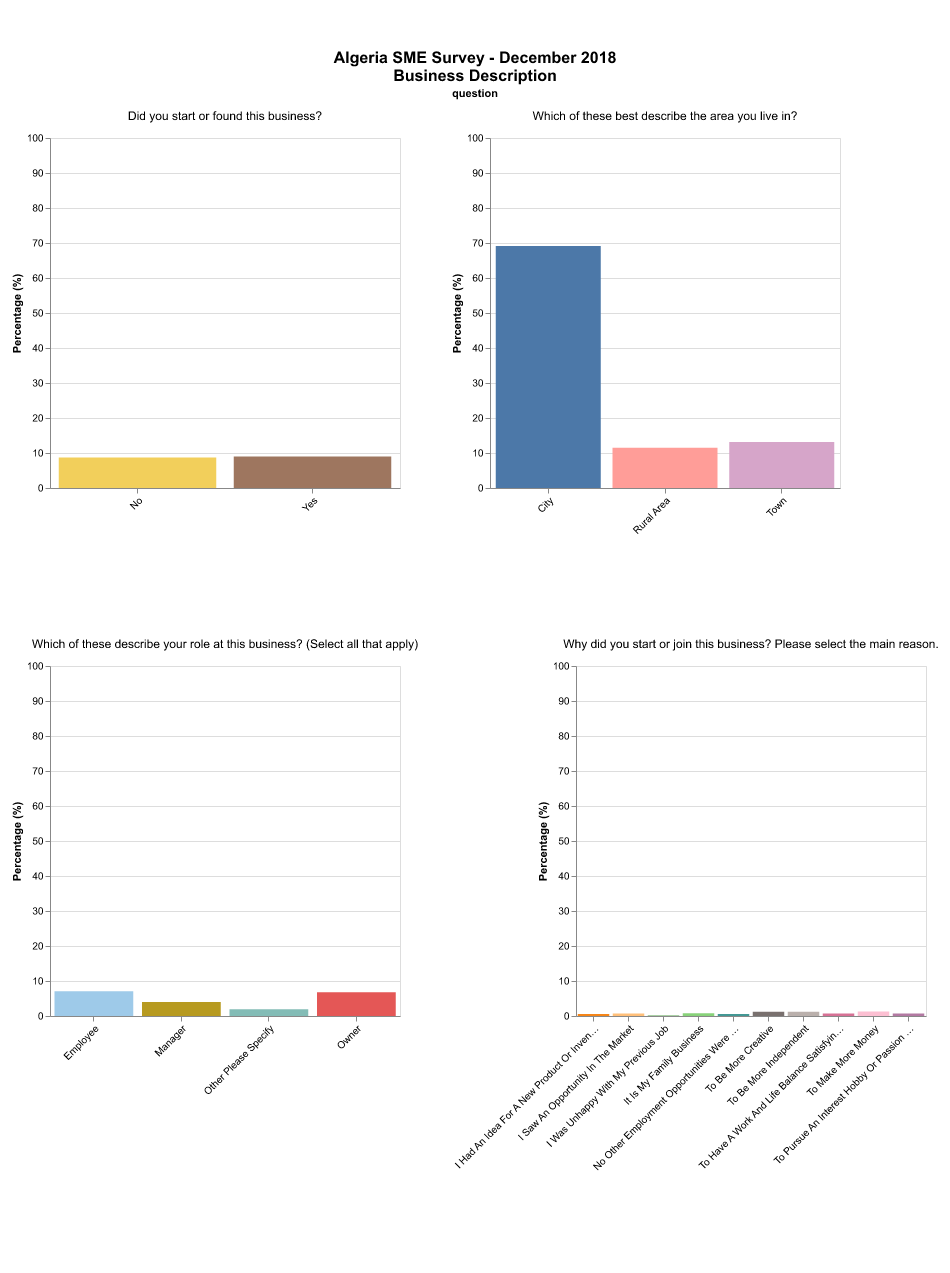

### Income

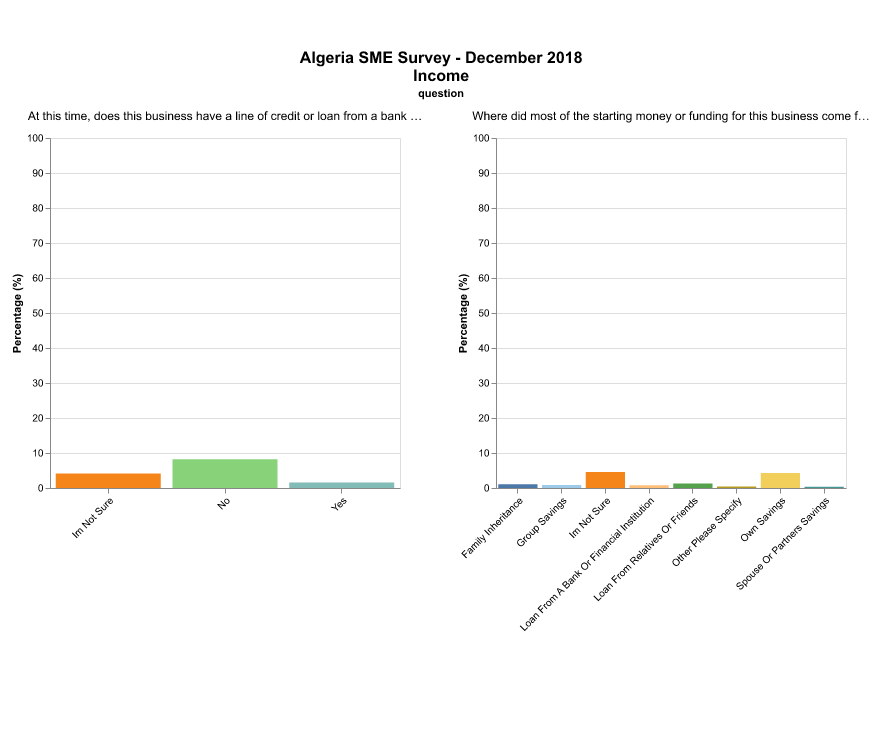

### Skills

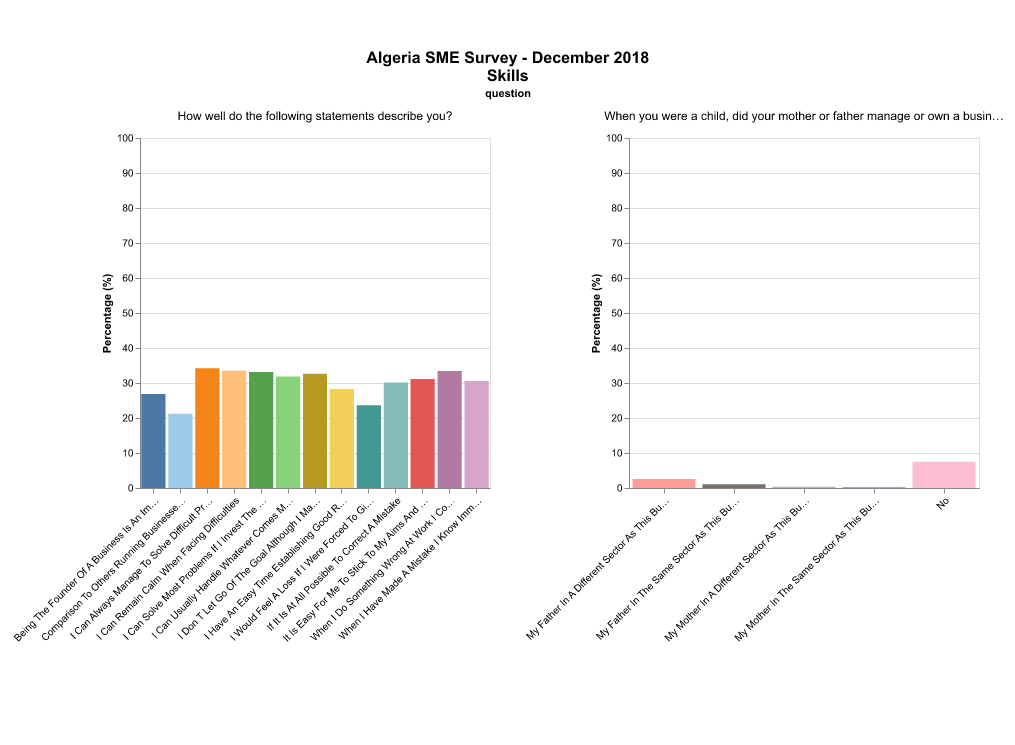

### Social Media

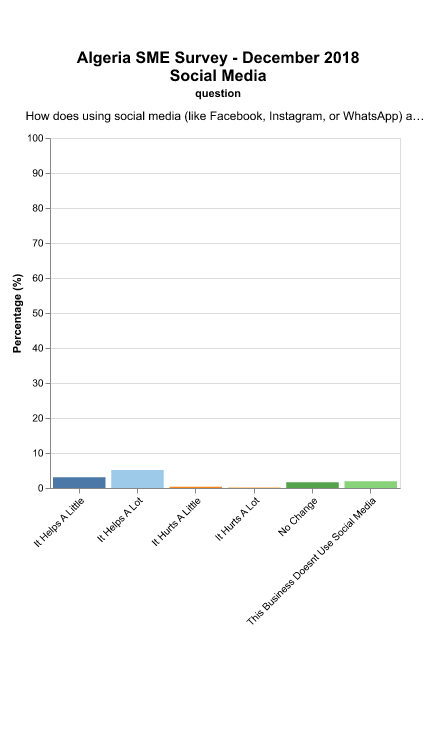

### Community

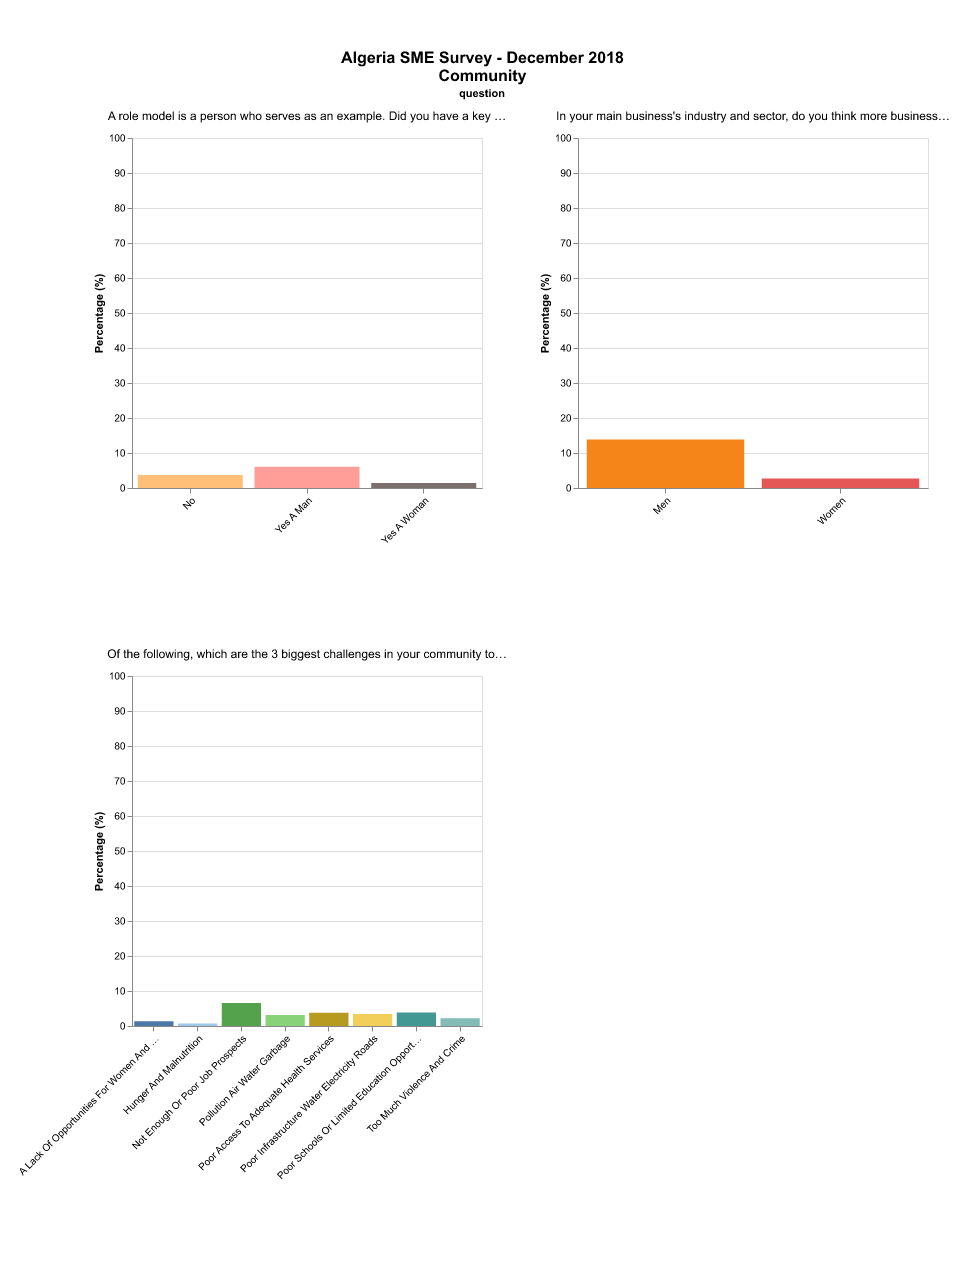

### Work Roles

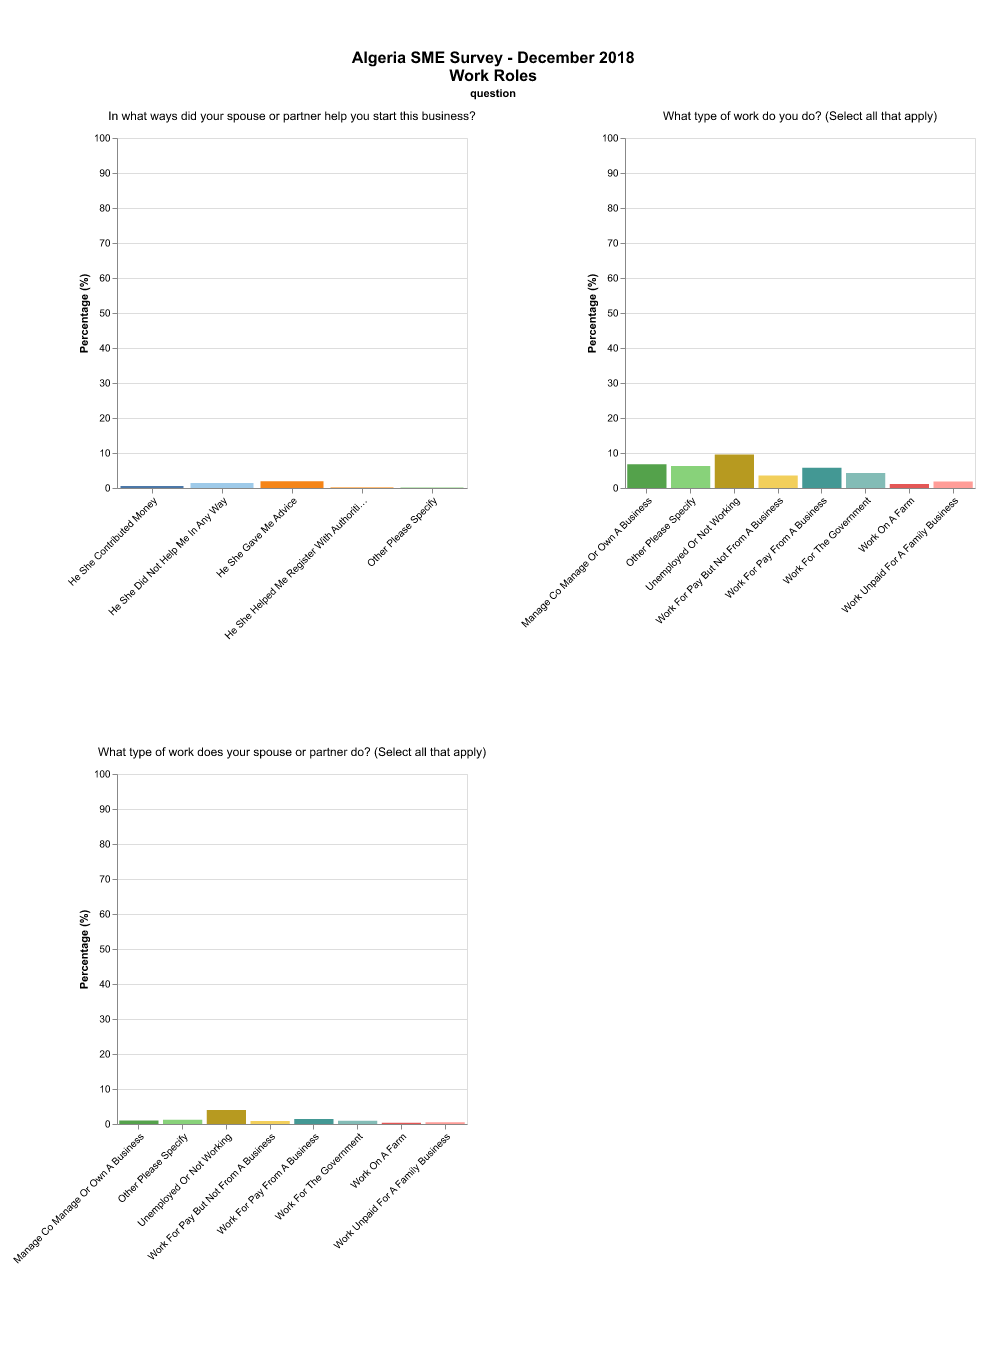

In [164]:
# Display charts by category
from IPython.display import Image, display, Markdown

categories_map = {
    'Business Description': 'business_description',
    'Income': 'income',
    'Skills': 'skills',
    'Social Media': 'social_media',
    'Community': 'community',
    'Work Roles': 'work_roles'
}

for display_name, category_key in categories_map.items():
    # Display category header
    display(Markdown(f"### {display_name}"))
    
    # Display PNG image
    filename = f"survey_charts_2018/{category_key}.png"
    display(Image(filename=filename))